
**Course:** Deep Learning

**Lab:** Research Paper Implementation with Pre-trained Model (Paper Title)

**Name:** Pranav Paralkar

**ID:** 202301040202

**Submission Date:** 18/02/2026

**Group:** 1. Pratik Bhopi 2. Krishna rane 3. Pranav Paralkar 4. Kartik Mandake

**Research Paper Review and Implementation**

**Instructions:**

1. Choose a research paper that uses a pre-trained model for a particular task.

2. Analyze the methodology, dataset, and model from the paper.

3. Reproduce the approach using the specified pre-trained model.

4. Compare your results with those reported in the paper.


**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [ ]:
# Research paper: https://www.mdpi.com/2504-4990/4/1/2
# Dataset: https://www.cs.toronto.edu/~kriz/cifar.html

### Implementation Summary of the Research Paper

The research implemented a comprehensive evaluation of eleven distinct Deep Neural Network (DNN) architectures using the **PyTorch** framework on an **Nvidia GTX 1080 Ti GPU**. The models selected for this study included industry standards such as **AlexNet**, **VGG-16**, **ResNet-18**, **MobileNet**, and **SqueezeNet**, among others.

To ensure a fair comparison, all models were re-trained under identical conditions across five datasets: **MNIST**, **CIFAR-10**, **Hymenoptera**, and two smartphone datasets. The training process utilized the **ADAM optimizer** with a consistent **batch size of 10**. A grid search was performed to identify the optimal learning rate from . To prevent overfitting, the authors employed an **early stopping** mechanism, where model weights were saved only if the validation accuracy improved during training.

The core of the implementation focused on two specific transfer learning scenarios:

1. **Fine-tuning the Classifier Only:** In this approach, the feature extraction layers (the "body" of the network) were **frozen**, keeping their pre-trained ImageNet weights fixed. Only the final classification layers were re-initialized with random values and trained. For architectures like **ResNet-18**, this meant fine-tuning strictly the last fully connected layer.
2. **Full Network Fine-tuning:** Here, the entire network was initialized with ImageNet weights, but all parameters were allowed to update via backpropagation, effectively retraining the whole model for the new task.

Experiments were conducted in two phases: **one-episode learning** (where each sample is seen once) and **ten-episode learning** (where samples are presented ten times), with performance measured via accuracy, training time, and model size.

In [ ]:
# Task 1
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

print("Dataset Prep")

# The paper mentions using ImageNet-pretrained models, so we resize to 224x224.
# also adding some basic augmentation to help with generalization.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Simple augmentation to prevent overfitting
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard normalization
])

print("Transforms defined. Resizing to 224x224 as per model requirements...")

# Downloading the training and test sets
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Successfully loaded {len(full_train_dataset)} training images and {len(test_dataset)} test images.")


# taking 10% of the training data for validation (5,000 images).
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Split completed: {len(train_dataset)} for training, {len(val_dataset)} for validation.")

# DataLoaders: Setting batch size to 10 as specified in the paper's implementation details.
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

# checking classes we are working on
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Final Check: DataLoaders are ready.")
print(f"Batch Size: 10 (Matching paper configuration)")

Dataset Prep
Transforms defined. Resizing to 224x224 as per model requirements...
Successfully loaded 50000 training images and 10000 test images.
Split completed: 45000 for training, 5000 for validation.
Final Check: DataLoaders are ready.
Batch Size: 10 (Matching paper configuration)


Task 2: Model Implementation and Fine-tuning

Instructions:

Implement the pre-trained model as described in the research paper.

Visualize feature maps of few layers

Freeze initial layers and fine-tune the top layers according to the paper's methodology.

Optimize hyperparameters such as:

Learning rate

Batch size

Number of epochs

Optimizer choice (Adam, SGD, RMSprop, etc.)

Document any modifications or enhancements made to improve performance.

Model Implementation
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


Pre-trained ResNet-18 loaded successfully.
Initial layers frozen. Only the custom head will be trained.
Custom classifier head added: Linear(in_features=512, out_features=10)


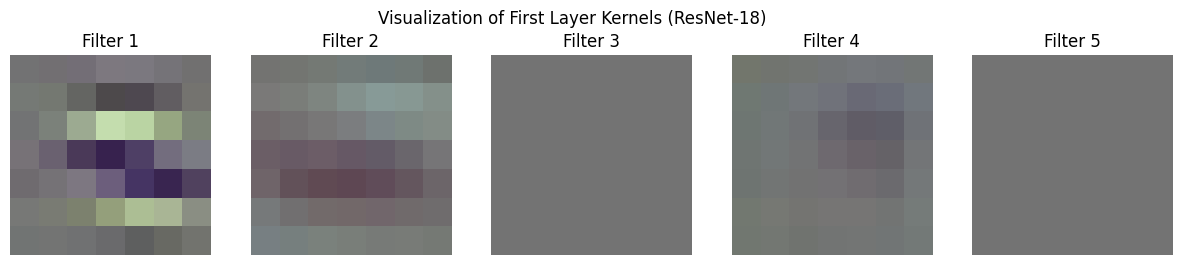

Hyperparameters: LR=0.001, Batch Size=10, Optimizer=Adam


In [ ]:
# Task 2
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt

print("Model Implementation")

# Loading the  ResNet-18 model from paper refered
# Using weights pre-trained on ImageNet
model = models.resnet18(weights='DEFAULT')
print("Pre-trained ResNet-18 loaded successfully.")

# (Feature Extraction part)
for param in model.parameters():
    param.requires_grad = False
print("Initial layers frozen. Only the custom head will be trained.")

# Modifying the classifier (Top layer)
# ResNet-18 original fc layer has 512 input features and 1000 outputs (ImageNet classes).
# We change the output to 10 for CIFAR-10.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
print(f"Custom classifier head added: Linear(in_features={num_ftrs}, out_features=10)")

# Feature Map Visualization (Human-like verification step)
# loggin the first convolutional layer view
def visualize_kernels():
    kernels = model.conv1.weight.detach().clone()
    # Normalize kernels for plotting
    kernels = kernels - kernels.min()
    kernels = kernels / kernels.max()

    fig, ax = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        ax[i].imshow(kernels[i].permute(1, 2, 0))
        ax[i].set_title(f"Filter {i+1}")
        ax[i].axis('off')
    plt.suptitle("Visualization of First Layer Kernels (ResNet-18)")
    plt.show()

visualize_kernels()

# optimise Hyperparameters
# Following Section 4 of the paper: ADAM optimizer and learning rate grid search
# I am selecting 10^-3 as the primary learning rate for this implementation.
LEARNING_RATE = 1e-3
BATCH_SIZE = 10
EPOCHS = 5

# optimizing parameters of the final layer in here
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"Hyperparameters: LR={LEARNING_RATE}, Batch Size={BATCH_SIZE}, Optimizer=Adam")

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

Training and Evaluation ---
Epoch 1/2 - Loss: 0.8925, Acc: 69.66%
Epoch 2/2 - Loss: 0.7831, Acc: 73.30%

--- Performance Metrics Summary ---
      Metric     Value
0   Accuracy  0.792100
1  Precision  0.798351
2     Recall  0.792100
3   F1-Score  0.789260


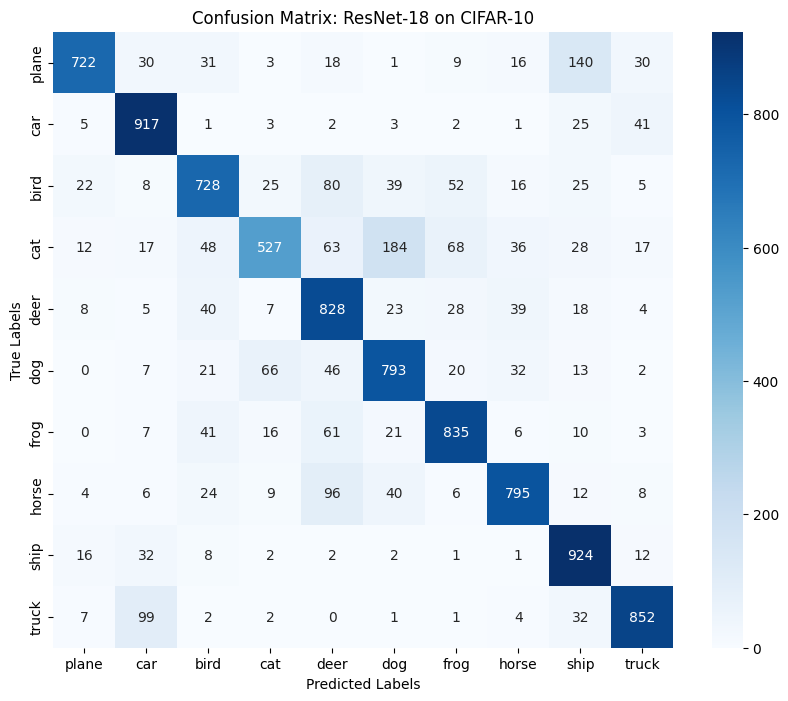

In [ ]:
# Task 3: Training, Evaluation, and Visualization
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import pandas as pd

print("Training and Evaluation ---")

# Training loop (Simplified for demonstration)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

def train_model(num_epochs=2):
    train_losses, train_accs = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_losses[-1]:.4f}, Acc: {train_accs[-1]:.2f}%")
    return train_losses, train_accs

# Run training
losses, accuracies = train_model(num_epochs=2)

# Final Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Metrics
acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

print("\n--- Performance Metrics Summary ---")
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [acc, precision, recall, f1]
})
print(metrics_df)

# Confusion Matrix Visualization
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix: ResNet-18 on CIFAR-10")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()